# Road Lane Detection — Day / Night Mode
### HSL Isolation | Gamma | CLAHE | Canny | Bird's Eye View | PolyFit | Drift Alert

---

**Fixes over the original notebook:**
- `Day / Night / Auto` mode selector widget (Cell 2) — forces or auto-detects the lighting condition
- Separate parameter configs per condition (thresholds, window margin, EMA alpha, gamma)
- **Curve fix**: removed incorrect curvature zeroing (`coeffs[0] = 0`), wider ROI, larger window margin, more windows, smarter pinch guard
- **Night fix**: gamma correction before CLAHE, stronger CLAHE clip, lower white/yellow HLS thresholds, mask dilation to fill dashed-line gaps

---

## Cell 1 — Dependencies & Imports

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets
import warnings
warnings.filterwarnings('ignore')

print(f'OpenCV : {cv2.__version__}')
print(f'NumPy  : {np.__version__}')
print('All dependencies loaded.')

OpenCV : 4.13.0
NumPy  : 2.2.6
All dependencies loaded.


## Cell 2 — Mode Selector

Choose **Day**, **Night**, or **Auto** (auto-detects by mean frame brightness).
Select the mode **before** running Cell 3 onward.

In [12]:
mode_widget = widgets.ToggleButtons(
    options=['Auto', 'Day', 'Night'],
    description='Mode:',
    button_style='info',
    value='Auto',
    tooltips=[
        'Auto-detect based on mean frame brightness (threshold: 70)',
        'Force day pipeline — bright / outdoor conditions',
        'Force night pipeline — dark, tunnel, or headlamp-only conditions',
    ]
)
display(mode_widget)
print('Select mode above, then run all remaining cells.')

ToggleButtons(button_style='info', description='Mode:', options=('Auto', 'Day', 'Night'), tooltips=('Auto-dete…

Select mode above, then run all remaining cells.


## Cell 3 — Configuration

Change `VIDEO_PATH` to switch between `Curve.MP4`, `Day.MP4`, or `Night.MP4`.
All tunable parameters live here.

In [13]:
# ── Input / output ──────────────────────────────────────────────────────────
# Switch VIDEO_PATH to test different clips:
#   'Dataset/Curve.MP4'
#   'Dataset/Day.MP4'
#   'Dataset/Night.MP4'
VIDEO_PATH  = '../Dataset/Day.MP4'
OUTPUT_PATH = '../result/lane_detection_output_Day.mp4'

# ── ROI trapezoid — fractions of (width, height) ────────────────────────────
# Wider top corners capture curves that exit a narrow horizon region.
ROI_TOP_LEFT     = (0.40, 0.46)
ROI_TOP_RIGHT    = (0.62, 0.46)
ROI_BOTTOM_LEFT  = (0.12, 0.76)
ROI_BOTTOM_RIGHT = (0.92, 0.76)

# ── Sliding-window & fit constants ──────────────────────────────────────────
N_WINDOWS            = 20    # more windows = finer curve tracking
MIN_PIX_WIN          = 20    # minimum pixels per window to recenter (lower helps at night)
MIN_PTS_FIT          = 30    # minimum edge pixels required to attempt a polynomial fit
DRIFT_THRESHOLD_FRAC = 0.08  # fraction of frame width before drift alert fires
VIZ_FRAME_IDX        = 250   # frame index used in the diagnostic grid

# ── Per-condition parameter sets ─────────────────────────────────────────────
DAY_CFG = {
    'white_l_min':   190,       # HLS L floor for white lanes
    'yellow_h':      (10, 45),  # HLS H range for yellow lanes
    'yellow_s_min':  100,       # HLS S floor for yellow lanes
    'canny_sigma':   0.33,      # Canny auto-threshold spread
    'window_margin': 80,        # +-px around window centre to search
    'ema_alpha':     0.30,      # EMA weight on the incoming frame (higher = more responsive)
    'clahe_clip':    2.0,
    'gamma':         1.0,       # no gamma correction needed in daylight
    'dilate_iter':   1,         # light dilation to connect short edge segments
}
NIGHT_CFG = {
    'white_l_min':   110,       # much lower — headlamp reflections are dimmer than sunlit paint
    'yellow_h':      (8, 50),   # wider hue band — sodium/LED lamps shift perceived yellow
    'yellow_s_min':  55,        # lower saturation — reflective night paint looks desaturated
    'canny_sigma':   0.18,      # tighter Canny to suppress noise on dark backgrounds
    'window_margin': 90,        # wider margin — lane position is harder to predict
    'ema_alpha':     0.40,      # more responsive — night lanes shift faster relative to noise
    'clahe_clip':    4.5,       # aggressive CLAHE to lift faint detail
    'gamma':         0.50,      # brighten the raw frame before CLAHE
    'dilate_iter':   3,         # fill the gaps in dashed night lane markers
}

def get_cfg(is_night):
    return NIGHT_CFG if is_night else DAY_CFG

print('Configuration set.')
print(f'  Input : {VIDEO_PATH}')
print(f'  Output: {OUTPUT_PATH}')

Configuration set.
  Input : ../Dataset/Day.MP4
  Output: ../result/lane_detection_output_Day.mp4


## Cell 4 — Core Pipeline Functions

In [14]:
def is_night_frame(gray):
    """Returns True when the pipeline should use the night config."""
    mode = mode_widget.value
    if mode == 'Night': return True
    if mode == 'Day':   return False
    return float(np.mean(gray)) < 70  # Auto


def apply_gamma(gray, gamma):
    """Power-law intensity mapping: brightens dark frames when gamma < 1."""
    if gamma == 1.0:
        return gray
    lut = (np.arange(256, dtype=np.float32) / 255.0) ** gamma * 255.0
    return lut.astype(np.uint8)[gray]


def adaptive_preprocess(frame, cfg):
    """
    1. Gamma correction (lifts dark frames before CLAHE).
    2. CLAHE on the corrected gray channel.
    3. Bilateral filter to smooth noise while preserving edges.
    4. HLS color mask for white and yellow lane paint.
    5. Morphological dilation to fill gaps in dashed lane markers.
    """
    gray     = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray_gc  = apply_gamma(gray, cfg['gamma'])
    clahe    = cv2.createCLAHE(clipLimit=cfg['clahe_clip'], tileGridSize=(8, 8))
    enhanced = clahe.apply(gray_gc)
    filtered = cv2.bilateralFilter(enhanced, 9, 75, 75)

    hls         = cv2.cvtColor(frame, cv2.COLOR_BGR2HLS)
    wl, yh, ys  = cfg['white_l_min'], cfg['yellow_h'], cfg['yellow_s_min']
    white_mask  = cv2.inRange(hls, np.array([0,     wl, 0]),  np.array([255, 255, 255]))
    yellow_mask = cv2.inRange(hls, np.array([yh[0], 0,  ys]), np.array([yh[1], 255, 255]))
    color_mask  = cv2.bitwise_or(white_mask, yellow_mask)

    if cfg['dilate_iter'] > 0:
        k          = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        color_mask = cv2.dilate(color_mask, k, iterations=cfg['dilate_iter'])

    return filtered, color_mask


def gaussian_blur(img, kernel=5):
    return cv2.GaussianBlur(img, (kernel, kernel), 0)


def adaptive_canny(blurred, sigma):
    """Otsu-like Canny: thresholds scaled around the median pixel value."""
    v  = np.median(blurred)
    lo = int(max(0,   (1 - sigma) * v))
    hi = int(min(255, (1 + sigma) * v))
    return cv2.Canny(blurred, lo, hi)


def get_perspective_matrices(shape):
    h, w = shape[:2]
    src = np.float32([
        [w * ROI_BOTTOM_LEFT[0],  h * ROI_BOTTOM_LEFT[1]],
        [w * ROI_TOP_LEFT[0],     h * ROI_TOP_LEFT[1]],
        [w * ROI_TOP_RIGHT[0],    h * ROI_TOP_RIGHT[1]],
        [w * ROI_BOTTOM_RIGHT[0], h * ROI_BOTTOM_RIGHT[1]],
    ])
    dst = np.float32([
        [w * 0.25, h],
        [w * 0.25, 0],
        [w * 0.75, 0],
        [w * 0.75, h],
    ])
    M    = cv2.getPerspectiveTransform(src, dst)
    Minv = cv2.getPerspectiveTransform(dst, src)
    return M, Minv


def apply_roi_mask(img, shape):
    """Zero out everything outside the ROI trapezoid before warping."""
    h, w = shape[:2]
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    pts  = np.array([[
        [int(w * ROI_BOTTOM_LEFT[0]),  int(h * ROI_BOTTOM_LEFT[1])],
        [int(w * ROI_TOP_LEFT[0]),     int(h * ROI_TOP_LEFT[1])],
        [int(w * ROI_TOP_RIGHT[0]),    int(h * ROI_TOP_RIGHT[1])],
        [int(w * ROI_BOTTOM_RIGHT[0]), int(h * ROI_BOTTOM_RIGHT[1])],
    ]], dtype=np.int32)
    cv2.fillPoly(mask, pts, 255)
    return cv2.bitwise_and(img, mask)


def sliding_window_cluster(warped_edges, window_margin):
    h, w       = warped_edges.shape
    histogram  = np.sum(warped_edges[h // 2:, :], axis=0)
    mid        = w // 2
    left_base  = int(np.argmax(histogram[:mid]))
    right_base = int(np.argmax(histogram[mid:])) + mid

    # Pinch guard: only reset to fixed defaults when BOTH histogram peaks are
    # genuinely absent (< 15 px).  Curves can legitimately bring lanes close
    # together in BEV, so distance alone is not a reliable trigger.
    if (right_base - left_base) < int(w * 0.25):
        if histogram[left_base] < 15 or histogram[right_base] < 15:
            left_base, right_base = int(w * 0.25), int(w * 0.75)

    window_h = h // N_WINDOWS
    nzy, nzx = warped_edges.nonzero()
    nzy, nzx = np.array(nzy), np.array(nzx)

    left_inds, right_inds = [], []
    lx, rx = left_base, right_base
    win_boxes = []

    for win in range(N_WINDOWS):
        y_lo  = h - (win + 1) * window_h
        y_hi  = h - win * window_h
        xl_lo = max(0, lx - window_margin)
        xl_hi = min(w, lx + window_margin)
        xr_lo = max(0, rx - window_margin)
        xr_hi = min(w, rx + window_margin)
        win_boxes.append(((xl_lo, y_lo, xl_hi, y_hi), (xr_lo, y_lo, xr_hi, y_hi)))

        gl = np.where((nzy >= y_lo) & (nzy < y_hi) & (nzx >= xl_lo) & (nzx < xl_hi))[0]
        gr = np.where((nzy >= y_lo) & (nzy < y_hi) & (nzx >= xr_lo) & (nzx < xr_hi))[0]
        left_inds.append(gl)
        right_inds.append(gr)
        if len(gl) >= MIN_PIX_WIN: lx = int(np.mean(nzx[gl]))
        if len(gr) >= MIN_PIX_WIN: rx = int(np.mean(nzx[gr]))

    li = np.concatenate(left_inds)  if left_inds  else np.array([], dtype=int)
    ri = np.concatenate(right_inds) if right_inds else np.array([], dtype=int)

    lpts = (nzx[li], nzy[li]) if len(li) else (np.array([]), np.array([]))
    rpts = (nzx[ri], nzy[ri]) if len(ri) else (np.array([]), np.array([]))
    return lpts, rpts, win_boxes


def fit_polynomial(lane_pts):
    xs, ys = lane_pts
    if len(xs) < MIN_PTS_FIT:
        return None
    try:
        coeffs = np.polyfit(ys, xs, 2)
        # Reject only physically impossible curvature (|a| > 0.005 ~ radius < 200px).
        # Do NOT zero small 'a' values — that killed curve detection in the original.
        if abs(coeffs[0]) > 0.005:
            return None
        return coeffs
    except Exception:
        return None


class LaneSmoother:
    """Per-frame exponential moving average over polynomial coefficients.

    Alpha is passed at update-time so day and night can use different speeds
    without needing separate smoother instances.
    """
    def __init__(self):
        self.l = self.r = None

    def update(self, nl, nr, alpha):
        def ema(prev, cur):
            if cur  is None: return prev
            if prev is None: return cur
            return alpha * cur + (1 - alpha) * prev
        self.l = ema(self.l, nl)
        self.r = ema(self.r, nr)
        return self.l, self.r


def detect_drift(bev_shape, lf, rf):
    h, w    = bev_shape[:2]
    car_cx  = w / 2.0
    y_ev    = float(h - 1)
    if lf is None or rf is None:
        return False, 'UNKNOWN', 0.0
    lane_cx = (np.polyval(lf, y_ev) + np.polyval(rf, y_ev)) / 2.0
    off     = car_cx - lane_cx
    if abs(off) > w * DRIFT_THRESHOLD_FRAC:
        return True, ('RIGHT' if off > 0 else 'LEFT'), float(off)
    return False, 'CENTER', float(off)


print('Core functions defined.')

Core functions defined.


## Cell 5 — Drawing & Unwarping Helpers

In [15]:
def draw_sliding_windows_bev(warped_edges, steps):
    viz    = cv2.cvtColor(warped_edges, cv2.COLOR_GRAY2BGR)
    for (bl, br) in steps['win_boxes']:
        cv2.rectangle(viz, (bl[0], bl[1]), (bl[2], bl[3]), (0, 220, 220), 2)
        cv2.rectangle(viz, (br[0], br[1]), (br[2], br[3]), (220, 0, 220), 2)
    lx, ly = steps['left_pts']
    rx, ry = steps['right_pts']
    for x, y in zip(lx, ly): cv2.circle(viz, (int(x), int(y)), 3, (0, 255, 80),  -1)
    for x, y in zip(rx, ry): cv2.circle(viz, (int(x), int(y)), 3, (80, 80, 255), -1)
    return viz


def draw_lane_overlay(frame, lf, rf, drift, Minv, is_night):
    h, w   = frame.shape[:2]
    canvas = np.zeros_like(frame)
    y_vals = np.linspace(0, h - 1, h)

    if lf is not None and rf is not None:
        lx = np.clip(np.polyval(lf, y_vals), 0, w - 1)
        rx = np.clip(np.polyval(rf, y_vals), 0, w - 1)
        pl = np.column_stack((lx, y_vals)).astype(np.int32)
        pr = np.column_stack((rx, y_vals)).astype(np.int32)
        cv2.fillPoly(canvas, [np.vstack([pl, pr[::-1]])], (0, 200, 60))
        cv2.polylines(canvas, [pl], False, (255, 200,   0), 30, cv2.LINE_AA)
        cv2.polylines(canvas, [pr], False, (  0, 100, 255), 30, cv2.LINE_AA)

    unwarped = cv2.warpPerspective(canvas, Minv, (w, h))
    result   = cv2.addWeighted(frame, 1.0, unwarped, 0.4, 0)

    is_d, direction, off = drift
    hud_col = (0, 50, 220) if is_d else (0, 200, 60)
    label   = f'DRIFT {direction}!' if is_d else 'On Lane'
    cv2.putText(result, f'{label} ({off:+.0f}px)', (int(w * 0.35), 60),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, hud_col, 3, cv2.LINE_AA)

    mode_str = 'NIGHT' if is_night else 'DAY'
    cv2.putText(result, f'Lane Detection | BEV | {mode_str} MODE', (10, h - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1, cv2.LINE_AA)
    return result


print('Drawing helpers ready.')

Drawing helpers ready.


## Cell 6 — Per-Frame Pipeline Orchestrator

In [16]:
def process_frame(frame, smoother, return_steps=False):
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    night = is_night_frame(gray)
    cfg   = get_cfg(night)

    filtered, color_mask = adaptive_preprocess(frame, cfg)
    blurred              = gaussian_blur(filtered)
    edges                = adaptive_canny(blurred, cfg['canny_sigma'])
    combined             = cv2.bitwise_and(edges, color_mask)
    combined_roi         = apply_roi_mask(combined, frame.shape)

    M, Minv = get_perspective_matrices(frame.shape)
    warped  = cv2.warpPerspective(combined_roi, M, (frame.shape[1], frame.shape[0]),
                                  flags=cv2.INTER_LINEAR)

    lpts, rpts, boxes = sliding_window_cluster(warped, cfg['window_margin'])
    lf, rf            = smoother.update(fit_polynomial(lpts), fit_polynomial(rpts),
                                        cfg['ema_alpha'])
    drift             = detect_drift(warped.shape, lf, rf)
    result            = draw_lane_overlay(frame, lf, rf, drift, Minv, night)

    steps = {}
    if return_steps:
        steps = {
            'color_mask':     color_mask,
            'combined_edges': combined_roi,
            'warped_edges':   warped,
            'win_boxes':      boxes,
            'left_pts':       lpts,
            'right_pts':      rpts,
        }
    return result, steps


print('Frame pipeline ready.')

Frame pipeline ready.


## Cell 7 — Step-by-Step Diagnostic Grid

Runs the full pipeline on a single frame and renders each intermediate stage.
Change `VIZ_FRAME_IDX` in Cell 3 to inspect a different moment in the video.

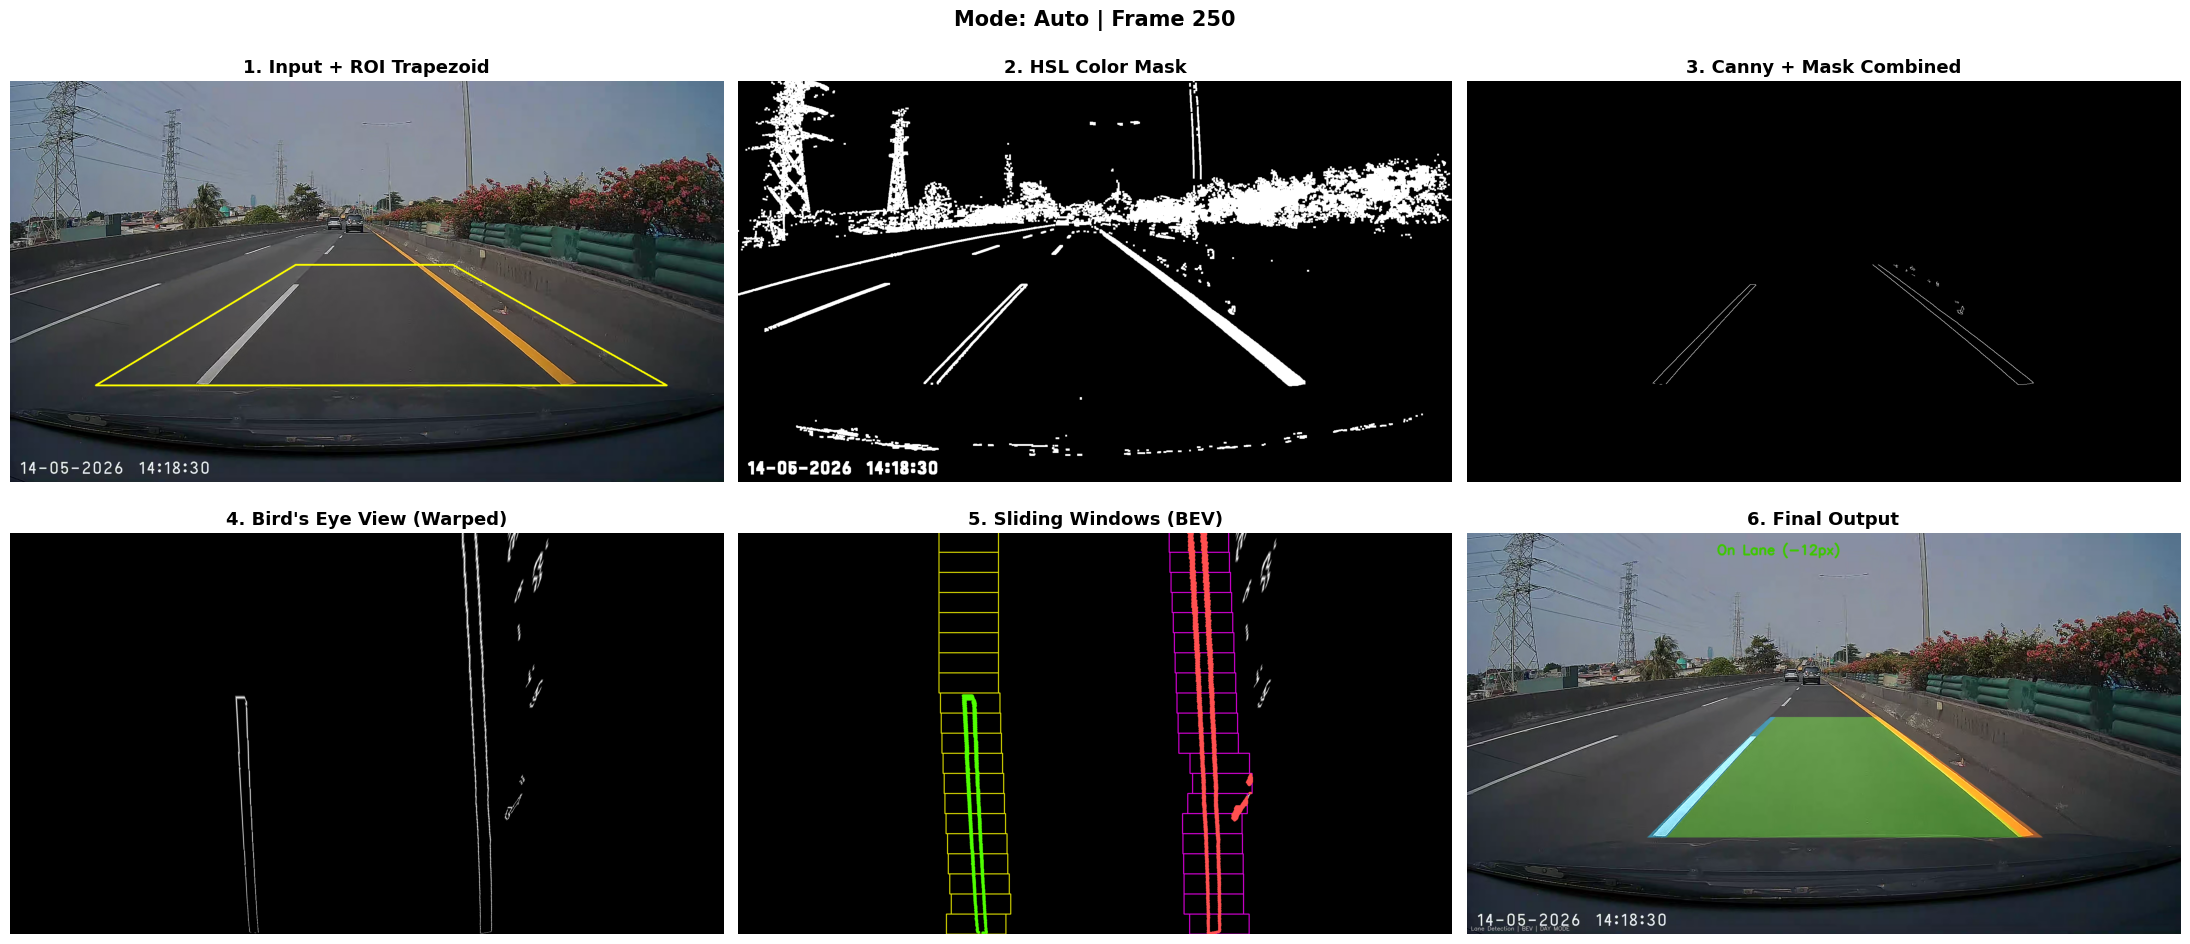

In [17]:
def show_pipeline_steps(frame, smoother):
    result, steps = process_frame(frame, smoother, return_steps=True)

    warp_src = frame.copy()
    h, w     = frame.shape[:2]
    roi_pts  = np.array([[
        (int(w * ROI_BOTTOM_LEFT[0]),  int(h * ROI_BOTTOM_LEFT[1])),
        (int(w * ROI_TOP_LEFT[0]),     int(h * ROI_TOP_LEFT[1])),
        (int(w * ROI_TOP_RIGHT[0]),    int(h * ROI_TOP_RIGHT[1])),
        (int(w * ROI_BOTTOM_RIGHT[0]), int(h * ROI_BOTTOM_RIGHT[1])),
    ]], np.int32)
    cv2.polylines(warp_src, roi_pts, isClosed=True, color=(0, 255, 255), thickness=3)

    titles = [
        '1. Input + ROI Trapezoid',
        '2. HSL Color Mask',
        '3. Canny + Mask Combined',
        "4. Bird's Eye View (Warped)",
        '5. Sliding Windows (BEV)',
        '6. Final Output',
    ]
    imgs = [
        warp_src,
        steps['color_mask'],
        steps['combined_edges'],
        steps['warped_edges'],
        draw_sliding_windows_bev(steps['warped_edges'], steps),
        result,
    ]

    fig, axes = plt.subplots(2, 3, figsize=(22, 10))
    for ax, img, title in zip(axes.flatten(), imgs, titles):
        if img.ndim == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontweight='bold', fontsize=13)
        ax.axis('off')
    plt.suptitle(f'Mode: {mode_widget.value} | Frame {VIZ_FRAME_IDX}',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()


cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, VIZ_FRAME_IDX)
ret, diag_frame = cap.read()
cap.release()

if ret:
    show_pipeline_steps(diag_frame, LaneSmoother())
else:
    print(f'Could not read frame {VIZ_FRAME_IDX} from {VIDEO_PATH} — check VIDEO_PATH.')

## Cell 8 — Full Video Export

Processes up to `duration` seconds and writes the result to `OUTPUT_PATH`.
Re-run with a different `VIDEO_PATH` and `mode_widget` selection to test Day/Night clips.

In [18]:
def process_video(video_path=VIDEO_PATH, out_path=OUTPUT_PATH, duration=60):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f'ERROR: Cannot open {video_path}')
        return

    fps   = cap.get(cv2.CAP_PROP_FPS) or 30.0
    fw    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    fh    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(duration * fps)
    out   = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (fw, fh))
    sm    = LaneSmoother()

    print(f'Processing: {video_path}')
    print(f'Mode     : {mode_widget.value}  |  {fw}x{fh} @ {fps:.1f} fps  |  {total} frames')
    print(f'Output   : {out_path}')
    print()

    for i in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        result, _ = process_frame(frame, sm)
        out.write(result)
        if i % int(fps * 10) == 0:
            print(f'  {i / total * 100:5.1f}%  ({i}/{total} frames)')

    cap.release()
    out.release()
    print()
    print(f'Done. Output saved to: {out_path}')


process_video()

Processing: ../Dataset/Day.MP4
Mode     : Auto  |  1920x1080 @ 30.0 fps  |  1800 frames
Output   : ../result/lane_detection_output_Day.mp4

    0.0%  (0/1800 frames)
   16.7%  (300/1800 frames)
   33.3%  (600/1800 frames)
   50.0%  (900/1800 frames)
   66.7%  (1200/1800 frames)
   83.3%  (1500/1800 frames)

Done. Output saved to: ../result/lane_detection_output_Day.mp4
